In [2]:
# ============================================================
# Homework Reflections 5-8
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from scipy.stats import skew
from collections import Counter

In [3]:
# ============================================================
# WEEK 5 HOMEWORK
# ============================================================

# Code to create data for this question 
num = 100000 
 
difficulty = np.random.uniform(0, 1, (num,)) 
 
speed = np.maximum(np.random.normal(15, 5, (num, )) - difficulty * 10, 0) 
 
accident = np.minimum(np.maximum(0.03 * speed + 0.4 * difficulty + np.random.normal(0, 0.3, (num,)), 0), 1) 
 
df = pd.DataFrame({'difficulty': difficulty, 'speed': speed, 'accident': accident}) 

In [4]:
# Question 1 

# Store regression coefficients
coefficients = []

# Number of repeated simulations
num_simulations = 100

for i in range(num_simulations):

    # Generate dataset
    num = 100000

    difficulty = np.random.uniform(0, 1, num)

    speed = np.maximum(
        np.random.normal(15, 5, num) - difficulty * 10,
        0
    )

    accident = np.minimum(
        np.maximum(
            0.03 * speed +
            0.4 * difficulty +
            np.random.normal(0, 0.3, num),
            0
        ),
        1
    )

    df = pd.DataFrame({
        'difficulty': difficulty,
        'speed': speed,
        'accident': accident
    })

    # Regress speed on difficulty
    X = sm.add_constant(df['difficulty'])
    y = df['speed']

    model = sm.OLS(y, X).fit()

    coefficients.append(model.params['difficulty'])

# Results
coef_df = pd.DataFrame({'difficulty_coef': coefficients})

print(coef_df.describe())

       difficulty_coef
count       100.000000
mean         -9.665717
std           0.052361
min          -9.787289
25%          -9.695588
50%          -9.667893
75%          -9.634736
max          -9.484555


In [5]:
# View Average Effect

print("Average coefficient:",
      np.mean(coefficients))

Average coefficient: -9.665716548635336


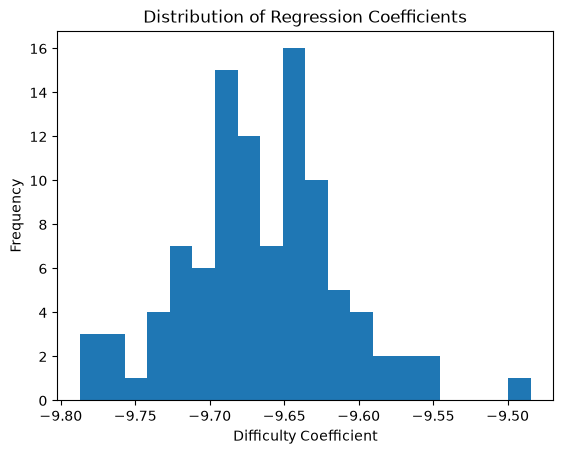

In [6]:
# Visualize Distribution

plt.hist(coefficients, bins=20)
plt.xlabel("Difficulty Coefficient")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Coefficients")
plt.show()

In [7]:
# Question 2 

difficulty_coefs = []

num_simulations = 100

for i in range(num_simulations):

    num = 100000

    difficulty = np.random.uniform(0, 1, num)

    speed = np.maximum(
        np.random.normal(15, 5, num) - difficulty * 10,
        0
    )

    accident = np.minimum(
        np.maximum(
            0.03 * speed +
            0.4 * difficulty +
            np.random.normal(0, 0.3, num),
            0
        ),
        1
    )

    df = pd.DataFrame({
        'difficulty': difficulty,
        'speed': speed,
        'accident': accident
    })

    X = sm.add_constant(df[['difficulty', 'accident']])
    y = df['speed']

    model = sm.OLS(y, X).fit()

    difficulty_coefs.append(model.params['difficulty'])

print("Average coefficient on difficulty:",
      np.mean(difficulty_coefs))

Average coefficient on difficulty: -10.326672534022068


In [ ]:
# Reflection Question 3: Simulation

np.random.seed(42)

num = 100000

# Lightning storm intensity, from 0 to 1
lightning = np.random.uniform(0, 1, num)

# Bears decrease when lightning increases
bears = np.maximum(
    50 - 25 * lightning + np.random.normal(0, 5, num),
    0
)

# Deer decrease when lightning increases and when bears increase
deer = np.maximum(
    100 - 30 * lightning - 0.5 * bears + np.random.normal(0, 10, num),
    0
)

# Flowers increase when lightning increases but decrease when deer increase
flowers = np.maximum(
    80 + 40 * lightning - 0.4 * deer + np.random.normal(0, 10, num),
    0
)

df = pd.DataFrame({
    "lightning": lightning,
    "bears": bears,
    "deer": deer,
    "flowers": flowers
})

df.head()

,lightning,bears,deer,flowers
0,0.374540,44.850053,87.057782,67.277799
1,0.950714,38.851577,42.685920,116.465533
2,0.731994,31.199494,59.024619,89.093943
3,0.598658,24.045516,66.197214,87.359058
4,0.156019,53.226271,71.162491,46.324377
